In [1]:
import os
os.getcwd()

'/Users/jadenb/Desktop/IT Projects/Google CERT'

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [52]:
def show_basics(df, target_col: str) -> None:
    print("Shape:", df.shape)
    print("\nHead:")
    display(df.head())
    print("\nMissing values (top 15):")
    display(df.isna().sum().sort_values(ascending=False).head(15))
    if target_col in df.columns:
        print("\nTarget counts:")
        display(df[target_col].value_counts())
        print("\nTarget proportions:")
        display(df[target_col].value_counts(normalize=True))

In [94]:
def clean_and_rename_columns(df):
    """
    standardize names
    """
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    rename_map = {
        "number_project": "num_projects",
        "average_montly_hours": "avg_monthly_hours",  
        "average_monthly_hours": "avg_monthly_hours",
        "time_spend_company": "tenure",
        "left": "attrition",
        "salary": "salary_level",
    }
    df = df.rename(columns=rename_map)
    return df

In [64]:
def drop_duplicates(df, verbose: bool = True):
    df = df.copy()
    dupes = df.duplicated().sum()
    if verbose:
        print("Duplicate rows:", dupes)
    df = df.drop_duplicates()
    if verbose:
        print("After drop_duplicates shape:", df.shape)
    return df

In [74]:
def cap_outliers(df, col: str, q: float = 0.99, verbose: bool = True):
    """
    Caps values above the q-quantile (e.g., 99th percentile).
    """
    df = df.copy()
    if col not in df.columns:
        raise KeyError(f"'{col}' not found.")

    upper = df[col].quantile(q)
    if verbose:
        print(f"{col} {int(q*100)}th percentile cap:", upper)
    df[col] = df[col].clip(upper=upper)
    return df

In [70]:
def encode_salary_ordinal(df, col: str = "salary_level", verbose: bool = True):
    """
    low/medium/high -> 0/1/2
    """
    df = df.copy()
    if col not in df.columns:
        if verbose:
            print(f"'{col}' not found.")
        return df

    salary_map = {"low": 0, "medium": 1, "high": 2}
    df[col] = df[col].map(salary_map)
    if verbose:
        print("Salary encoding applied:", salary_map)
        print("salary_level unique (after):", df[col].dropna().unique())
    return df

In [16]:
def one_hot_encode(df, cat_cols: list[str], drop_first: bool = True, verbose: bool = True):
    df = df.copy()
    existing = [c for c in cat_cols if c in df.columns]
    if verbose:
        print("One-hot encoding columns:", existing)
    df = pd.get_dummies(df, columns=existing, drop_first=drop_first)
    return df

In [78]:
def split_xy(df, target: str = "attrition"):
    if target not in df.columns:
        raise KeyError(f"Target '{target}' not found.")
    X = df.drop(columns=[target])
    y = df[target]
    return X, y


In [20]:
def train_test_split_stratified(X, y, test_size=0.2, random_state=42):
    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

In [22]:
def eval_preds(y_true, y_pred, label: str = "Model"):
    print(f"\n=== {label} ===")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:\n", cm)
    return {
        "report_dict": classification_report(y_true, y_pred, output_dict=True),
        "confusion_matrix": cm
    }

In [96]:

def top_logreg_coefficients(model: LogisticRegression, feature_names, top_n: int = 10):
    """
    Returns top coefficients by absolute value.
    """
    coefs = model.coef_[0]
    dfc = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)
    return dfc.head(top_n)

In [80]:
def rf_feature_importance(model: RandomForestClassifier, feature_names, top_n: int = 10):
    imp = model.feature_importances_
    dfi = pd.DataFrame({
        "feature": feature_names,
        "importance": imp
    }).sort_values("importance", ascending=False)
    return dfi.head(top_n)

In [28]:
def plot_rf_importance_bar(dfi_top: pd.DataFrame, title: str = "Top Feature Importances (Random Forest)"):
    import matplotlib.pyplot as plt
    ax = dfi_top.set_index("feature")["importance"].sort_values().plot(kind="barh", figsize=(8, 5), legend=False)
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [30]:
def business_recommendations_from_findings(top_drivers: list[str]) -> list[str]:
    """
    Manual recommendations (no API/LLM) based on typical drivers you already identified.
    """
    recs = []

    if any("satisfaction" in d for d in top_drivers):
        recs.append("Run monthly pulse surveys and trigger manager follow-ups for low satisfaction scores; prioritize teams with repeated low signals.")
    if any("avg_monthly_hours" in d or "hours" in d for d in top_drivers):
        recs.append("Set workload guardrails (monthly hours thresholds) and monitor overtime; rebalance staffing for consistently over-cap teams.")
    if any("num_projects" in d for d in top_drivers):
        recs.append("Cap concurrent projects per employee and formalize resource planning to prevent chronic overload.")
    if any("tenure" in d for d in top_drivers):
        recs.append("Add mid-tenure (years 2–4) career paths: mentorship, internal mobility, and milestone-based growth plans.")
    if any("salary" in d for d in top_drivers):
        recs.append("Review compensation bands vs. market and address compression; target adjustments for high-risk roles and critical teams.")
    if any("department" in d for d in top_drivers):
        recs.append("Deploy department-specific retention plans for high-risk groups (e.g., Sales/Technical): manager coaching + growth + workload fixes.")

    # Ensure 5 concise recs
    while len(recs) < 5:
        recs.append("Improve manager effectiveness via coaching, 1:1 quality checks, and accountability metrics tied to retention outcomes.")
    return recs[:5]


In [100]:
DATA_PATH = "data/HR_comma_sep.csv"

df = pd.read_csv(DATA_PATH)

# Quick baseline (before rename)
print("Original columns:")
print(df.columns.tolist())


# 2) Clean / Rename Columns
df = clean_and_rename_columns(df)

print("\nCleaned columns:")
print(df.columns.tolist())

# 3) Initial Observations
show_basics(df, target_col="attrition")

# 4) Duplicates
df = drop_duplicates(df, verbose=True)

Original columns:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Cleaned columns:
['satisfaction_level', 'last_evaluation', 'num_projects', 'avg_monthly_hours', 'tenure', 'work_accident', 'attrition', 'promotion_last_5years', 'department', 'salary_level']
Shape: (14999, 10)

Head:


,satisfaction_level,last_evaluation,num_projects,avg_monthly_hours,tenure,work_accident,attrition,promotion_last_5years,department,salary_level
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Missing values (top 15):


satisfaction_level       0
last_evaluation          0
num_projects             0
avg_monthly_hours        0
tenure                   0
work_accident            0
attrition                0
promotion_last_5years    0
department               0
salary_level             0
dtype: int64


Target counts:


attrition
0    11428
1     3571
Name: count, dtype: int64


Target proportions:


attrition
0    0.761917
1    0.238083
Name: proportion, dtype: float64

Duplicate rows: 3008
After drop_duplicates shape: (11991, 10)


In [102]:
# -------------------------
# 5) Feature Engineering / Encoding

# 5a) Outlier capping for avg_monthly_hours (99th percentile)
df = cap_outliers(df, col="avg_monthly_hours", q=0.99, verbose=True)

# 5b) Salary ordinal encoding (low/medium/high -> 0/1/2)
df = encode_salary_ordinal(df, col="salary_level", verbose=True)

# 5c) One-hot encode department (drop_first True like you did)
# NOTE: In the raw dataset it's typically "sales", "technical", etc. under column "department".
df = one_hot_encode(df, cat_cols=["department"], drop_first=True, verbose=True)

print("\nFinal feature columns preview:")
print(df.columns.tolist())

avg_monthly_hours 99th percentile cap: 296.0
Salary encoding applied: {'low': 0, 'medium': 1, 'high': 2}
salary_level unique (after): [0 1 2]
One-hot encoding columns: ['department']

Final feature columns preview:
['satisfaction_level', 'last_evaluation', 'num_projects', 'avg_monthly_hours', 'tenure', 'work_accident', 'attrition', 'promotion_last_5years', 'salary_level', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical']


In [106]:
# -------------------------
# 6) Split X/y + Train/Test Split (Stratified)

X, y = split_xy(df, target="attrition")
print("\nX shape, y shape:", X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split_stratified(X, y, test_size=0.2, random_state=42)

print("\nTrain/Test shapes:", X_train.shape, X_test.shape)
print("\nTrain proportions:")
display(y_train.value_counts(normalize=True))
print("\nTest proportions:")
display(y_test.value_counts(normalize=True))


X shape, y shape: (11991, 17) (11991,)

Train/Test shapes: (9592, 17) (2399, 17)

Train proportions:


attrition
0    0.833924
1    0.166076
Name: proportion, dtype: float64


Test proportions:


attrition
0    0.834098
1    0.165902
Name: proportion, dtype: float64

In [108]:
# -------------------------
# 7) Logistic Regression (Scaled)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
lr_results = eval_preds(y_test, y_pred_lr, label="Logistic Regression (class_weight=balanced)")

# Coefficients (interpretability)
coef_df = top_logreg_coefficients(log_reg, feature_names=X.columns, top_n=10)
display(coef_df)


=== Logistic Regression (class_weight=balanced) ===
              precision    recall  f1-score   support

           0       0.96      0.77      0.86      2001
           1       0.42      0.84      0.56       398

    accuracy                           0.78      2399
   macro avg       0.69      0.81      0.71      2399
weighted avg       0.87      0.78      0.81      2399

Confusion matrix:
 [[1543  458]
 [  63  335]]


,feature,coefficient,abs_coef
0,satisfaction_level,-1.075800,1.075800
4,tenure,0.894024,0.894024
2,num_projects,-0.520802,0.520802
5,work_accident,-0.485772,0.485772
7,salary_level,-0.389526,0.389526
3,avg_monthly_hours,0.210602,0.210602
1,last_evaluation,0.208647,0.208647
6,promotion_last_5years,-0.173028,0.173028
8,department_RandD,-0.097477,0.097477
11,department_management,-0.084379,0.084379



=== Random Forest (class_weight=balanced) ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399

Confusion matrix:
 [[1994    7]
 [  31  367]]


,feature,importance
0,satisfaction_level,0.281568
4,tenure,0.255166
2,num_projects,0.156144
3,avg_monthly_hours,0.141270
1,last_evaluation,0.134606
7,salary_level,0.010717
5,work_accident,0.009182
14,department_sales,0.002510
16,department_technical,0.001981
15,department_support,0.001586


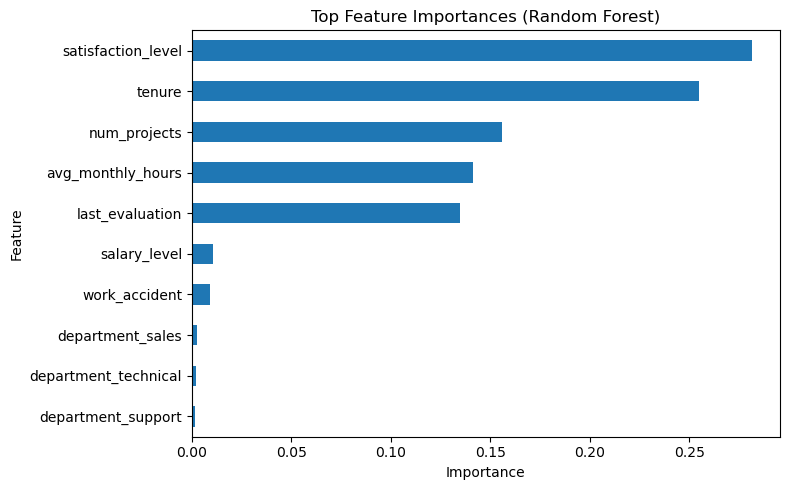

In [110]:
# -------------------------
# 8) Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_results = eval_preds(y_test, y_pred_rf, label="Random Forest (class_weight=balanced)")

rf_top = rf_feature_importance(rf, feature_names=X.columns, top_n=10)
display(rf_top)
plot_rf_importance_bar(rf_top, title="Top Feature Importances (Random Forest)")

In [90]:
def summarize_for_resume(results_dict: dict, positive_class: str = "1") -> dict:
    r = results_dict["report_dict"]
    return {
        "accuracy": r["accuracy"],
        "attrition_precision": r[positive_class]["precision"],
        "attrition_recall": r[positive_class]["recall"],
        "attrition_f1": r[positive_class]["f1-score"],
    }

lr_metrics = summarize_for_resume(lr_results)
rf_metrics = summarize_for_resume(rf_results)

print("\nResume-ready metrics:")
print("LogReg:", lr_metrics)
print("RandForest:", rf_metrics)


Resume-ready metrics:
LogReg: {'accuracy': 0.7828261775739892, 'attrition_precision': 0.4224464060529634, 'attrition_recall': 0.8417085427135679, 'attrition_f1': 0.5625524769101595}
RandForest: {'accuracy': 0.984160066694456, 'attrition_precision': 0.9812834224598931, 'attrition_recall': 0.9221105527638191, 'attrition_f1': 0.9507772020725389}


In [44]:
# -------------------------
# 10) Business Recommendations (Manual, Based on Drivers)
# -------------------------
# Pick top drivers from BOTH models (combined)
top_lr_features = coef_df["feature"].head(6).tolist()
top_rf_features = rf_top["feature"].head(6).tolist()
combined_drivers = list(dict.fromkeys(top_lr_features + top_rf_features))  # preserve order, remove dupes

print("\nTop drivers (combined):", combined_drivers)

recs = business_recommendations_from_findings(combined_drivers)
print("\nBusiness Recommendations:")
for i, r in enumerate(recs, 1):
    print(f"{i}. {r}")


# -------------------------
# 11) Notes / Limitations (optional to print)
# -------------------------
print("\nLimitations / Next Steps:")
print("- Single dataset/source; generalization may vary by company/industry.")
print("- Consider threshold tuning (optimize for recall vs precision) and cost-sensitive evaluation.")
print("- Consider SHAP for deeper interpretability (esp. Random Forest).")
print("- Consider cross-validation + hyperparameter tuning for more robust performance estimates.")


Top drivers (combined): ['satisfaction_level', 'tenure', 'num_projects', 'work_accident', 'salary_level', 'avg_monthly_hours', 'last_evaluation']

Business Recommendations:
1. Run monthly pulse surveys and trigger manager follow-ups for low satisfaction scores; prioritize teams with repeated low signals.
2. Set workload guardrails (monthly hours thresholds) and monitor overtime; rebalance staffing for consistently over-cap teams.
3. Cap concurrent projects per employee and formalize resource planning to prevent chronic overload.
4. Add mid-tenure (years 2–4) career paths: mentorship, internal mobility, and milestone-based growth plans.
5. Review compensation bands vs. market and address compression; target adjustments for high-risk roles and critical teams.

Limitations / Next Steps:
- Single dataset/source; generalization may vary by company/industry.
- Consider threshold tuning (optimize for recall vs precision) and cost-sensitive evaluation.
- Consider SHAP for deeper interpretabil